# Analyse Éthique du Turnover — HumanForYou
## Pipeline complète : EDA → Régression → Classification

**Objectif** : Identifier les facteurs de départ des employés et proposer des leviers d'action RH.

**Dataset** : 5 fichiers CSV (general_data, employee_survey, manager_survey, in_time, out_time)

# Partie 1 — Analyse Exploratoire des Données (EDA)

> Inspiré du Workshop « Utilisation IA — Exploratory Data Analysis »

## 1.1 Environnement et imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

%matplotlib inline

print("Environnement prêt ✓")

Environnement prêt ✓


## 1.2 Chargement des données

In [2]:
# Chargement des 5 fichiers CSV
general = pd.read_csv('../data/general_data.csv')
emp_survey = pd.read_csv('../data/employee_survey_data.csv')
mgr_survey = pd.read_csv('../data/manager_survey_data.csv')
in_time = pd.read_csv('../data/in_time.csv')
out_time = pd.read_csv('../data/out_time.csv')

print(f"general_data      : {general.shape}")
print(f"employee_survey   : {emp_survey.shape}")
print(f"manager_survey    : {mgr_survey.shape}")
print(f"in_time           : {in_time.shape}")
print(f"out_time          : {out_time.shape}")

general_data      : (4410, 24)
employee_survey   : (4410, 4)
manager_survey    : (4410, 3)
in_time           : (4410, 262)
out_time          : (4410, 262)


## 1.3 Exploration initiale

In [ ]:
# Aperçu de chaque table
for name, df in [('general', general), ('emp_survey', emp_survey),
                  ('mgr_survey', mgr_survey), ('in_time', in_time), ('out_time', out_time)]:
    print(f"\n{'='*60}")
    print(f" {name} — {df.shape[0]} lignes x {df.shape[1]} colonnes")
    print(f"{'='*60}")
    print(df.dtypes.value_counts().to_string())
    print(f"\nValeurs manquantes : {df.isnull().sum().sum()}")


 general — 4410 lignes × 24 colonnes
int64      14
str         8
float64     2

Valeurs manquantes : 28

 emp_survey — 4410 lignes × 4 colonnes
float64    3
int64      1

Valeurs manquantes : 83

 mgr_survey — 4410 lignes × 3 colonnes
int64    3

Valeurs manquantes : 0

 in_time — 4410 lignes × 262 colonnes
str        249
float64     12
int64        1

Valeurs manquantes : 109080

 out_time — 4410 lignes × 262 colonnes
str        249
float64     12
int64        1

Valeurs manquantes : 109080


In [4]:
general.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4


In [5]:
general.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,4410.0,NaN,NaN,NaN,36.92381,9.133301,18.0,30.0,36.0,43.0,60.0
Attrition,4410,2,No,3699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,4410,3,Travel_Rarely,3129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,4410,3,Research & Development,2883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,4410.0,NaN,NaN,NaN,9.192517,8.105026,1.0,2.0,7.0,14.0,29.0
Education,4410.0,NaN,NaN,NaN,2.912925,1.023933,1.0,2.0,3.0,4.0,5.0
EducationField,4410,6,Life Sciences,1818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,4410.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeID,4410.0,NaN,NaN,NaN,2205.5,1273.201673,1.0,1103.25,2205.5,3307.75,4410.0
Gender,4410,2,Male,2646,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.4 Feature Engineering — Heures de travail

Les fichiers `in_time` et `out_time` contiennent les horodatages d'entrée/sortie pour chaque jour ouvré de 2015.  
On va en extraire des métriques agrégées par employé :
- **avg_work_hours** : nombre moyen d'heures travaillées par jour
- **std_work_hours** : écart-type des heures travaillées (régularité)
- **days_absent** : nombre de jours d'absence (NaN dans in_time)

In [6]:
# Renommer la première colonne (non nommée) en EmployeeID
in_time = in_time.rename(columns={in_time.columns[0]: 'EmployeeID'})
out_time = out_time.rename(columns={out_time.columns[0]: 'EmployeeID'})

# Convertir les colonnes de dates en datetime
date_cols = in_time.columns[1:]

in_time_dt = in_time.copy()
out_time_dt = out_time.copy()
for col in date_cols:
    in_time_dt[col] = pd.to_datetime(in_time_dt[col], errors='coerce')
    out_time_dt[col] = pd.to_datetime(out_time_dt[col], errors='coerce')

# Calcul des heures travaillées par jour
work_hours = pd.DataFrame()
work_hours['EmployeeID'] = in_time_dt['EmployeeID']

for col in date_cols:
    diff = (out_time_dt[col] - in_time_dt[col]).dt.total_seconds() / 3600
    work_hours[col] = diff

# Agrégation par employé
time_features = pd.DataFrame()
time_features['EmployeeID'] = work_hours['EmployeeID']
time_features['avg_work_hours'] = work_hours[date_cols].mean(axis=1)
time_features['std_work_hours'] = work_hours[date_cols].std(axis=1)
time_features['days_absent'] = work_hours[date_cols].isnull().sum(axis=1)

print(time_features.describe())
time_features.head()

        EmployeeID  avg_work_hours  std_work_hours  days_absent
count  4410.000000     4410.000000     4410.000000  4410.000000
mean   2205.500000        7.700792        0.299578    24.734694
std    1273.201673        1.340218        0.013721     5.503779
min       1.000000        5.950504        0.254754    13.000000
25%    1103.250000        6.673333        0.289964    20.000000
50%    2205.500000        7.406761        0.299544    25.000000
75%    3307.750000        8.368703        0.308990    29.000000
max    4410.000000       11.030960        0.344907    36.000000


,EmployeeID,avg_work_hours,std_work_hours,days_absent
0,1,7.373651,0.283224,29
1,2,7.718969,0.313351,25
2,3,7.013240,0.311551,19
3,4,7.193678,0.284133,26
4,5,8.006175,0.300656,16


## 1.5 Fusion des datasets

On fusionne toutes les tables sur `EmployeeID` pour obtenir un dataset unique.

In [7]:
# Fusion progressive sur EmployeeID
df = general.merge(emp_survey, on='EmployeeID', how='left')
df = df.merge(mgr_survey, on='EmployeeID', how='left')
df = df.merge(time_features, on='EmployeeID', how='left')

print(f"Dataset fusionné : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
df.head()

Dataset fusionné : (4410, 32)
Colonnes : ['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_work_hours', 'std_work_hours', 'days_absent']


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,avg_work_hours,std_work_hours,days_absent
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3,7.373651,0.283224,29
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4,7.718969,0.313351,25
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3,7.013240,0.311551,19
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5,4.0,4.0,3.0,2,3,7.193678,0.284133,26
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4,4.0,1.0,3.0,3,3,8.006175,0.300656,16


## 1.6 Analyse des valeurs manquantes

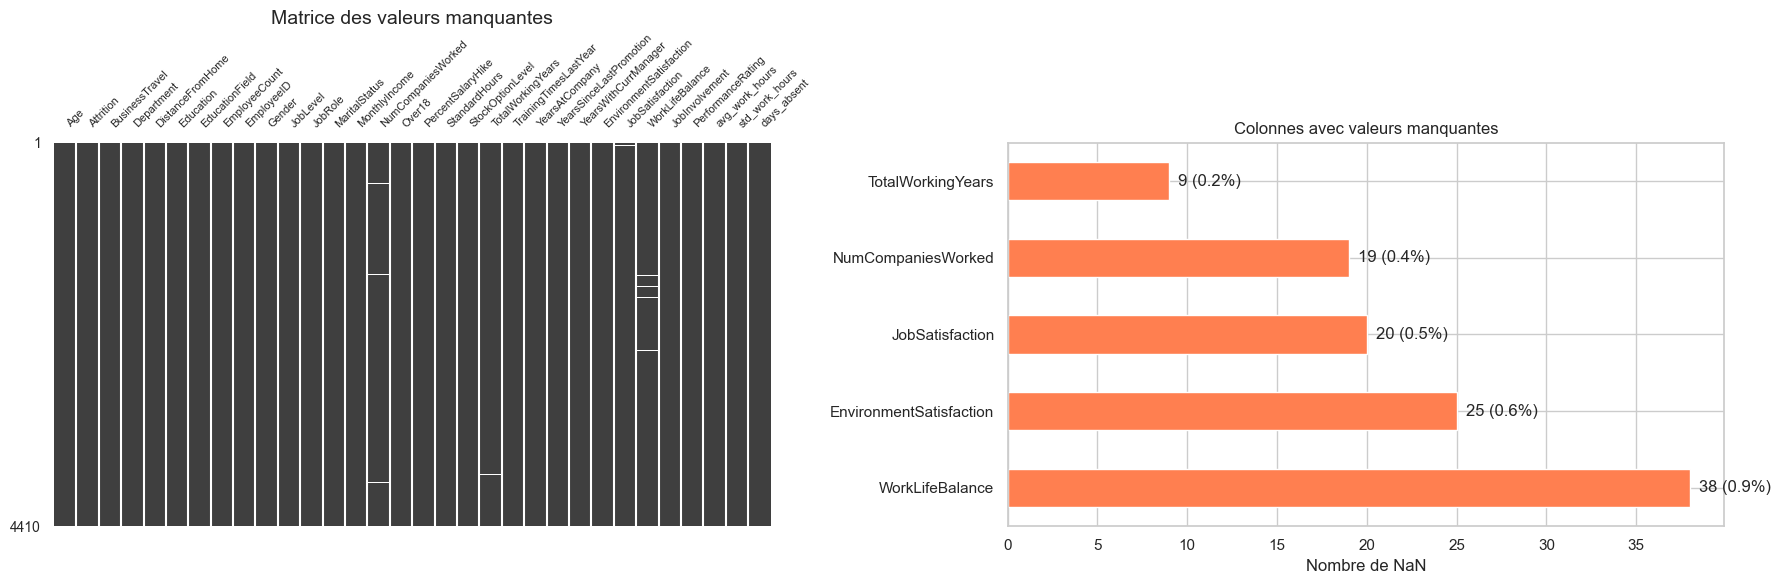

In [ ]:
# Matrice de valeurs manquantes
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

msno.matrix(df, ax=axes[0], sparkline=False, fontsize=8)
axes[0].set_title('Matrice des valeurs manquantes', fontsize=14)

# Barplot des valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    missing.plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Colonnes avec valeurs manquantes')
    axes[1].set_xlabel('Nombre de NaN')
    for i, v in enumerate(missing):
        axes[1].text(v + 0.5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center')
else:
    axes[1].text(0.5, 0.5, 'Aucune valeur manquante !', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=14)
plt.tight_layout()
plt.show()

## 1.7 Nettoyage des données

1. **Imputation** des valeurs manquantes numériques par la médiane
2. **Suppression** des colonnes constantes (EmployeeCount, StandardHours, Over18)
3. **Suppression** de EmployeeID (identifiant, pas une feature)
4. **Encodage** de la variable cible `Attrition` en binaire (Yes=1, No=0)

In [9]:
# Encoder Attrition en binaire
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Identifier les colonnes constantes
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Colonnes constantes : {constant_cols}")

# Identifier les colonnes quasi-constantes
quasi_constant = [col for col in df.columns if df[col].nunique() == 2 and col != 'Attrition']
print(f"Colonnes quasi-constantes (2 valeurs uniques) : {quasi_constant}")

# Supprimer colonnes inutiles
cols_to_drop = constant_cols + ['EmployeeID']
# Vérifier aussi Over18 et StandardHours si pas déjà dans constant_cols
for c in ['Over18', 'StandardHours', 'EmployeeCount']:
    if c in df.columns and c not in cols_to_drop:
        cols_to_drop.append(c)

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f"\nColonnes supprimées : {cols_to_drop}")
print(f"Dataset après nettoyage : {df.shape}")

Colonnes constantes : ['EmployeeCount', 'Over18', 'StandardHours']
Colonnes quasi-constantes (2 valeurs uniques) : ['Gender', 'PerformanceRating']

Colonnes supprimées : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']
Dataset après nettoyage : (4410, 28)


In [10]:
# Imputation des valeurs manquantes numériques par la médiane
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        count = df[col].isnull().sum()
        df[col].fillna(median_val, inplace=True)
        print(f"{col}: {count} NaN remplacés par médiane = {median_val}")

# Vérification
print(f"\nValeurs manquantes restantes : {df.isnull().sum().sum()}")

NumCompaniesWorked: 19 NaN remplacés par médiane = 2.0
TotalWorkingYears: 9 NaN remplacés par médiane = 10.0
EnvironmentSatisfaction: 25 NaN remplacés par médiane = 3.0
JobSatisfaction: 20 NaN remplacés par médiane = 3.0
WorkLifeBalance: 38 NaN remplacés par médiane = 3.0

Valeurs manquantes restantes : 111


## 1.8 Analyse univariée

### Distribution de la variable cible (Attrition)

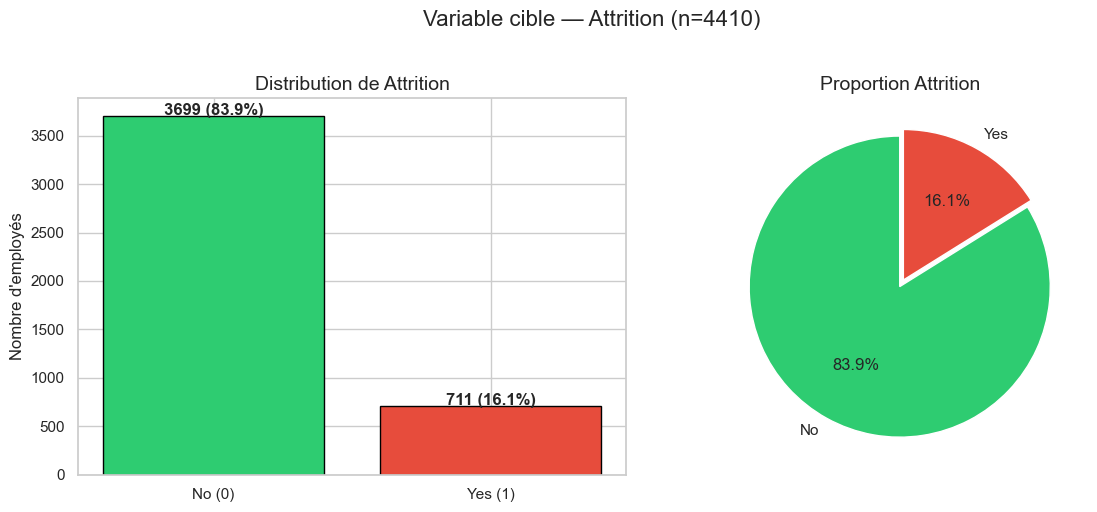


⚠️ Déséquilibre de classes : 5.2:1 (No:Yes)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
counts = df['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['No (0)', 'Yes (1)'], counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribution de Attrition', fontsize=14)
axes[0].set_ylabel('Nombre d\'employés')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No', 'Yes'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0, 0.05])
axes[1].set_title('Proportion Attrition', fontsize=14)

plt.suptitle(f'Variable cible — Attrition (n={len(df)})', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n⚠️ Déséquilibre de classes : {counts[0]/counts[1]:.1f}:1 (No:Yes)")

### Distribution des variables numériques

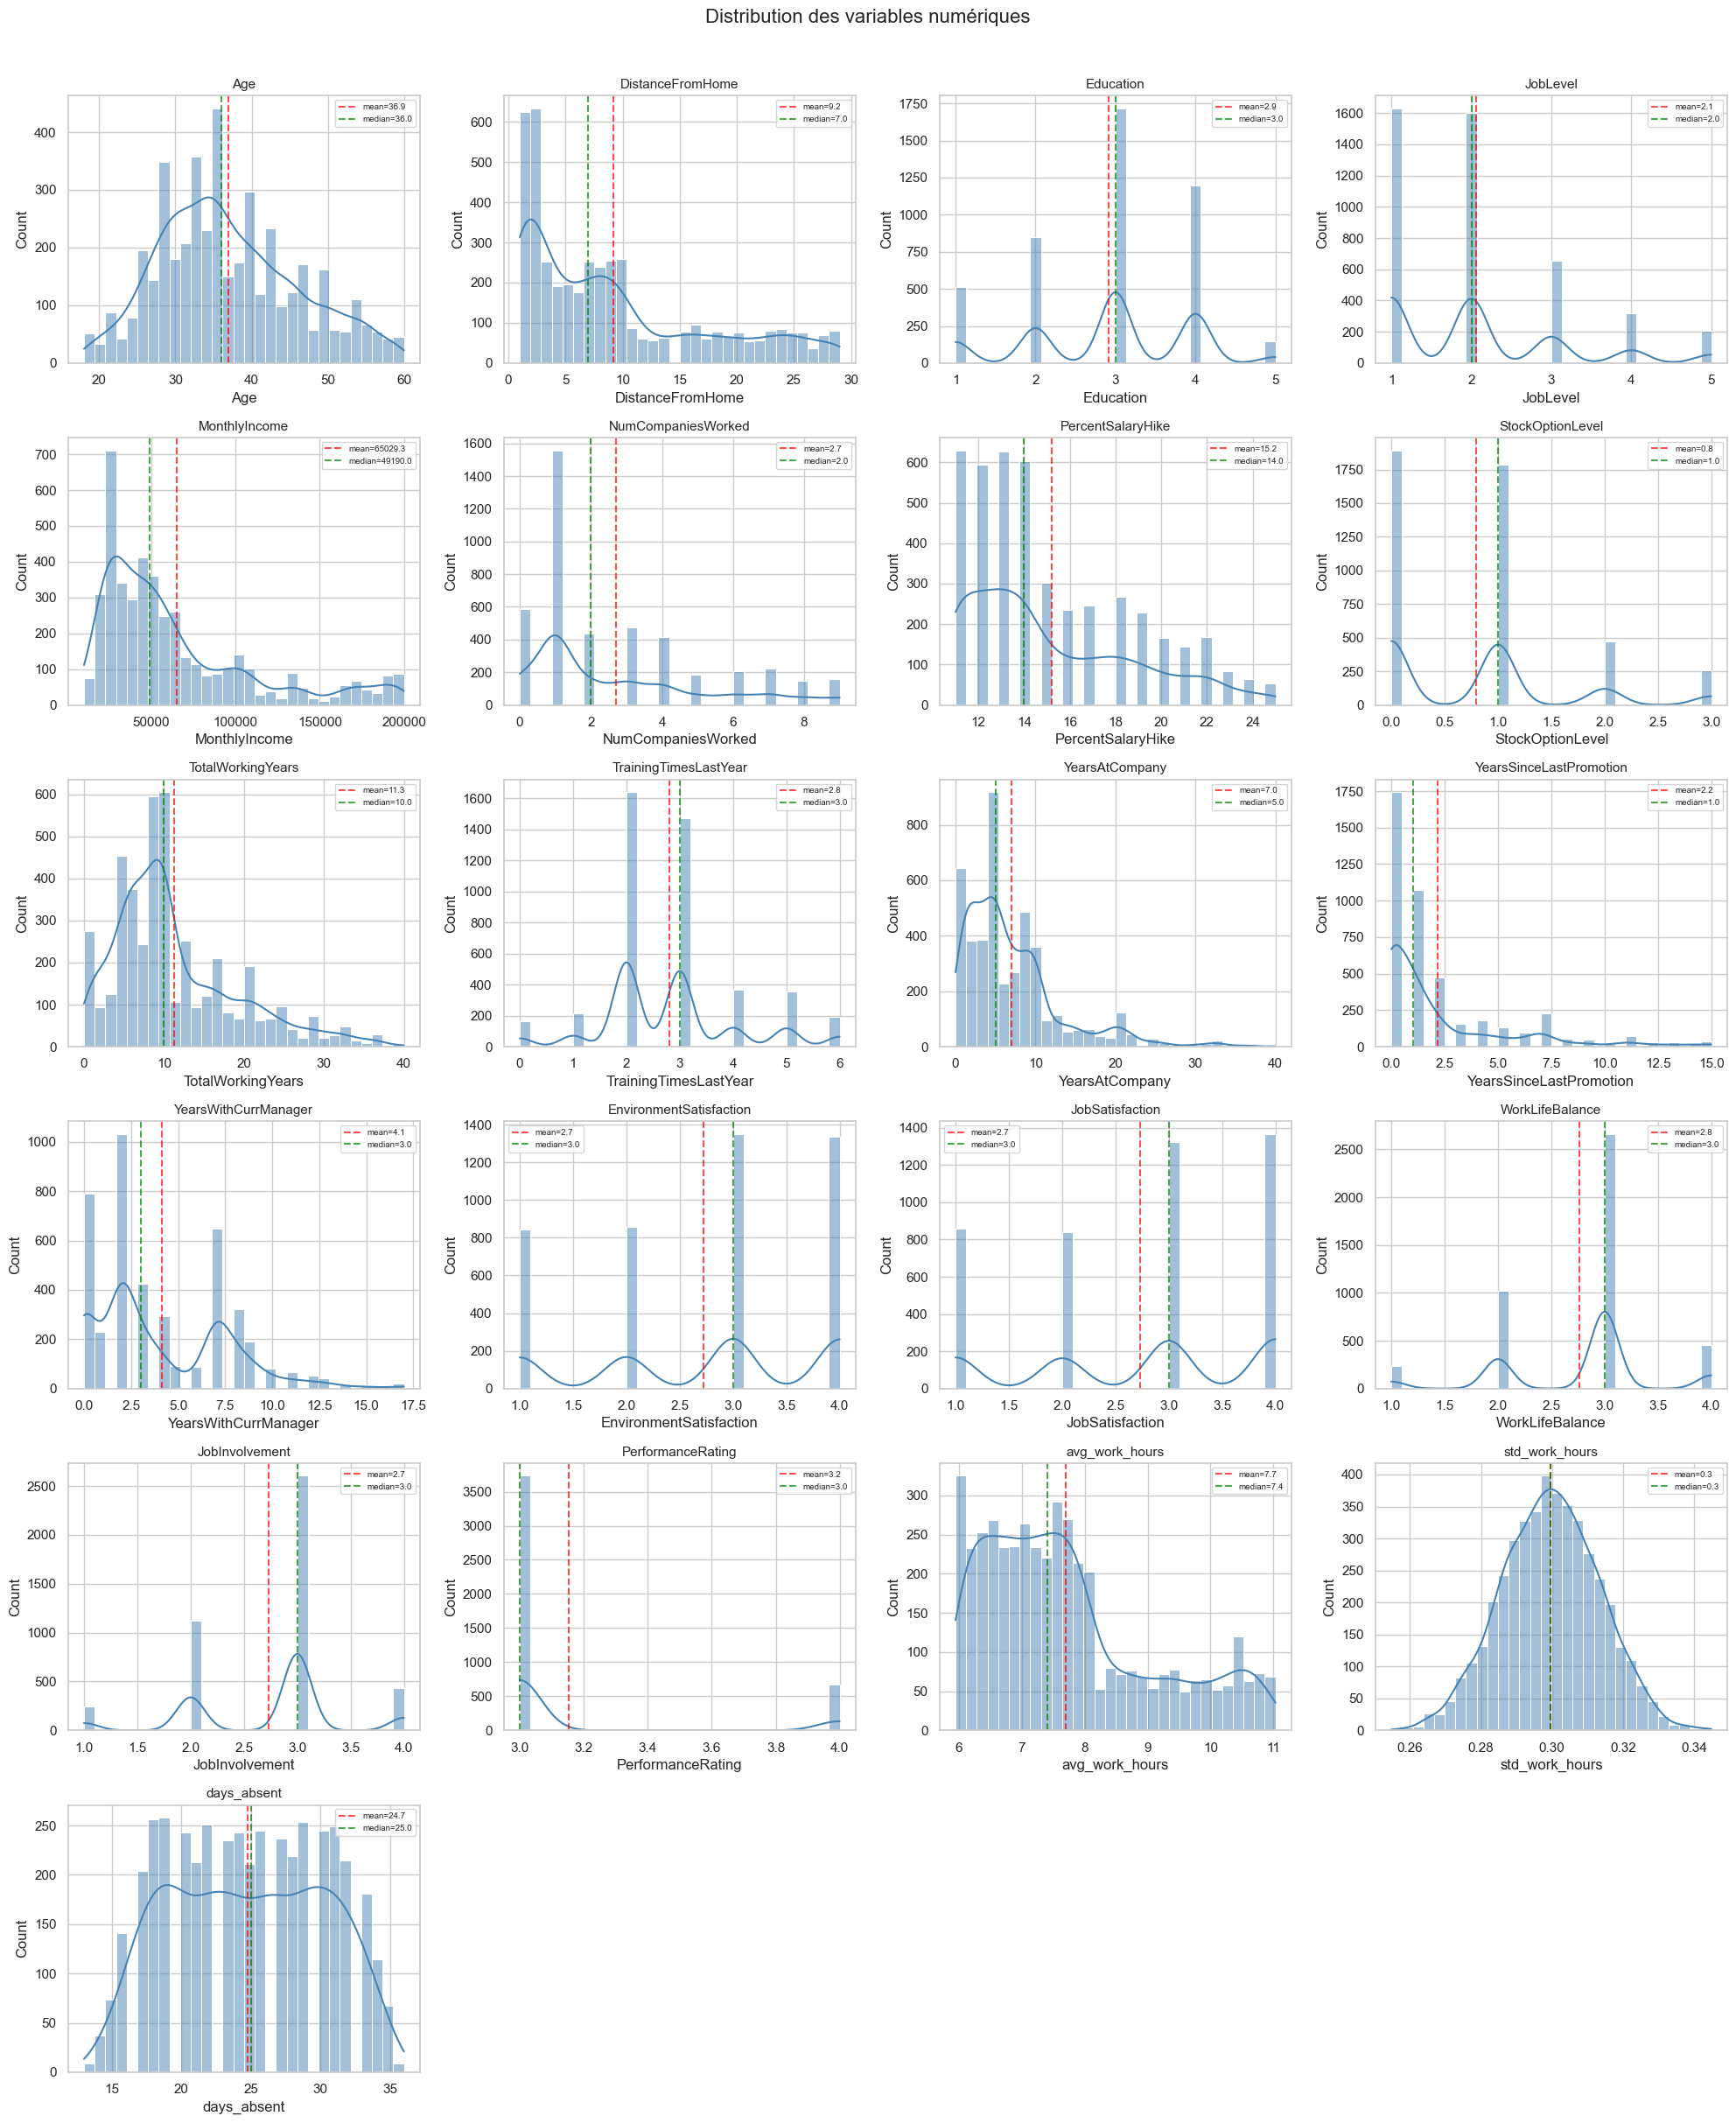

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_no_target = [c for c in num_cols if c != 'Attrition']

n_cols = 4
n_rows = (len(num_cols_no_target) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_no_target):
    sns.histplot(df[col], ax=axes[i], kde=True, bins=30, color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', alpha=0.7, label=f'mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', alpha=0.7, label=f'median={df[col].median():.1f}')
    axes[i].legend(fontsize=7)

# Masquer les axes inutilisés
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables numériques', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Distribution des variables catégorielles

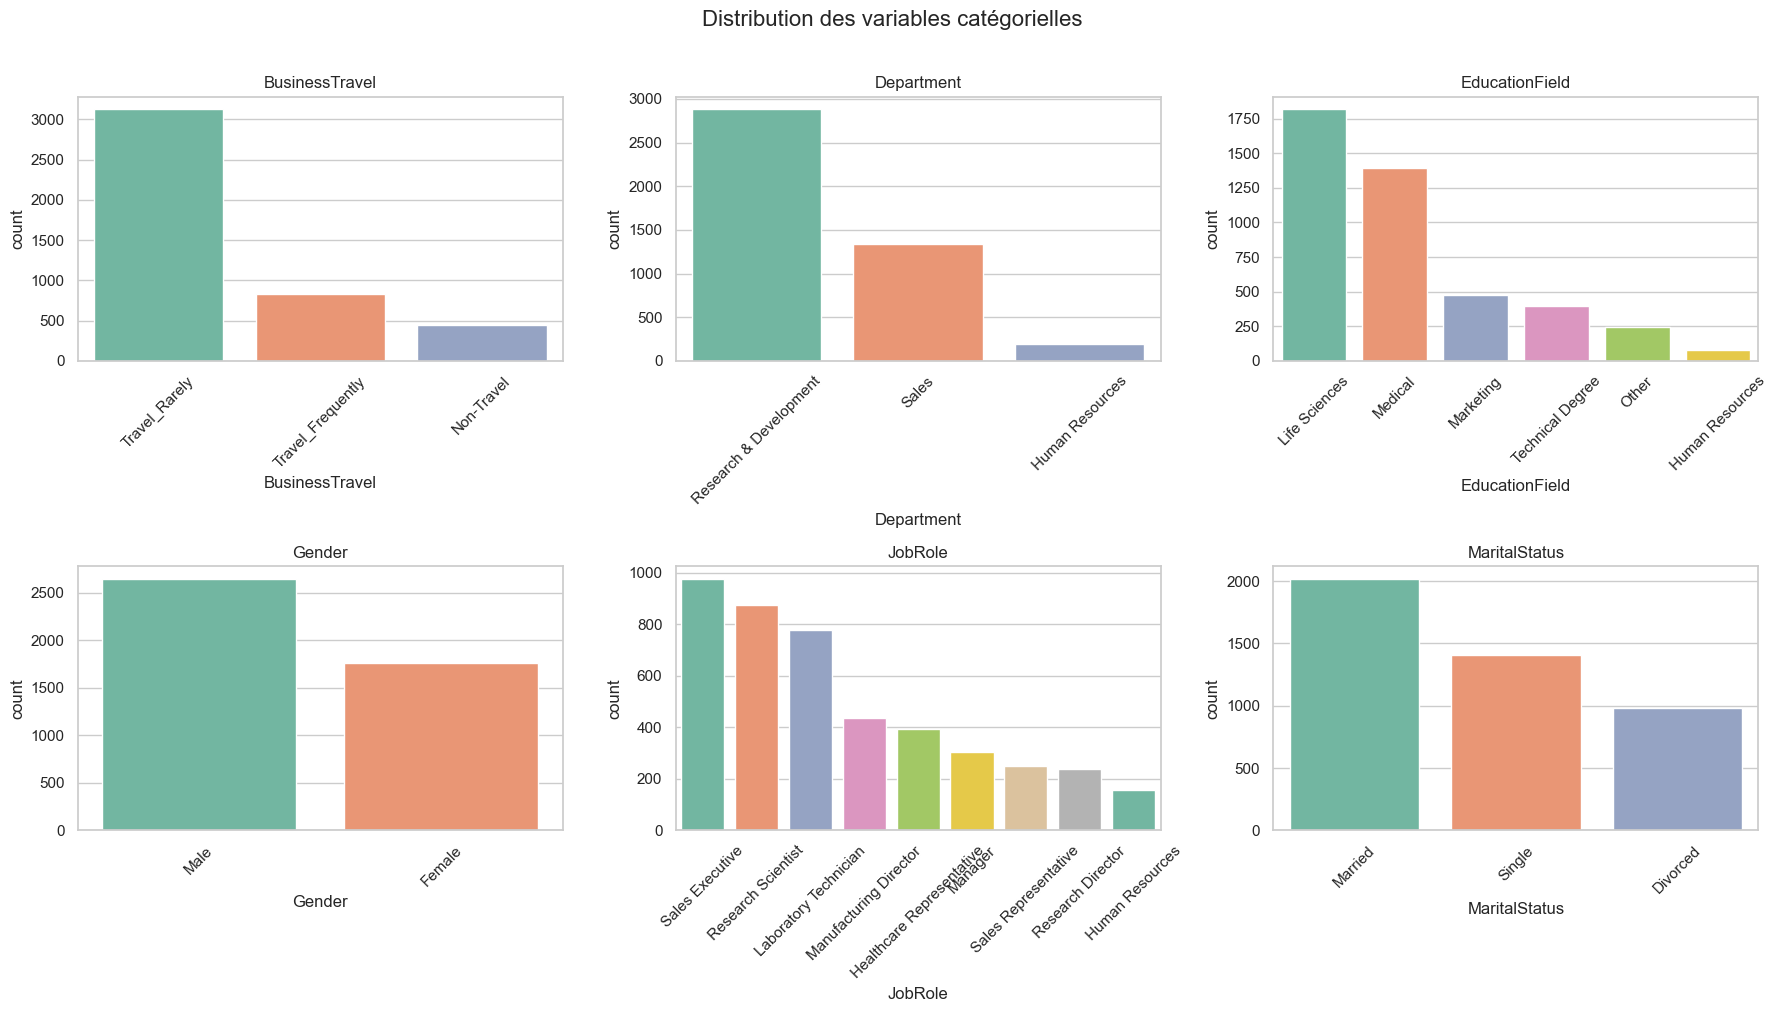

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(cat_cols) > 0:
    n_cols_plot = 3
    n_rows_plot = (len(cat_cols) + n_cols_plot - 1) // n_cols_plot
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='Set2')
        axes[i].set_title(col, fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution des variables catégorielles', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune variable catégorielle restante.")

## 1.9 Analyse bivariée

### Matrice de corrélation

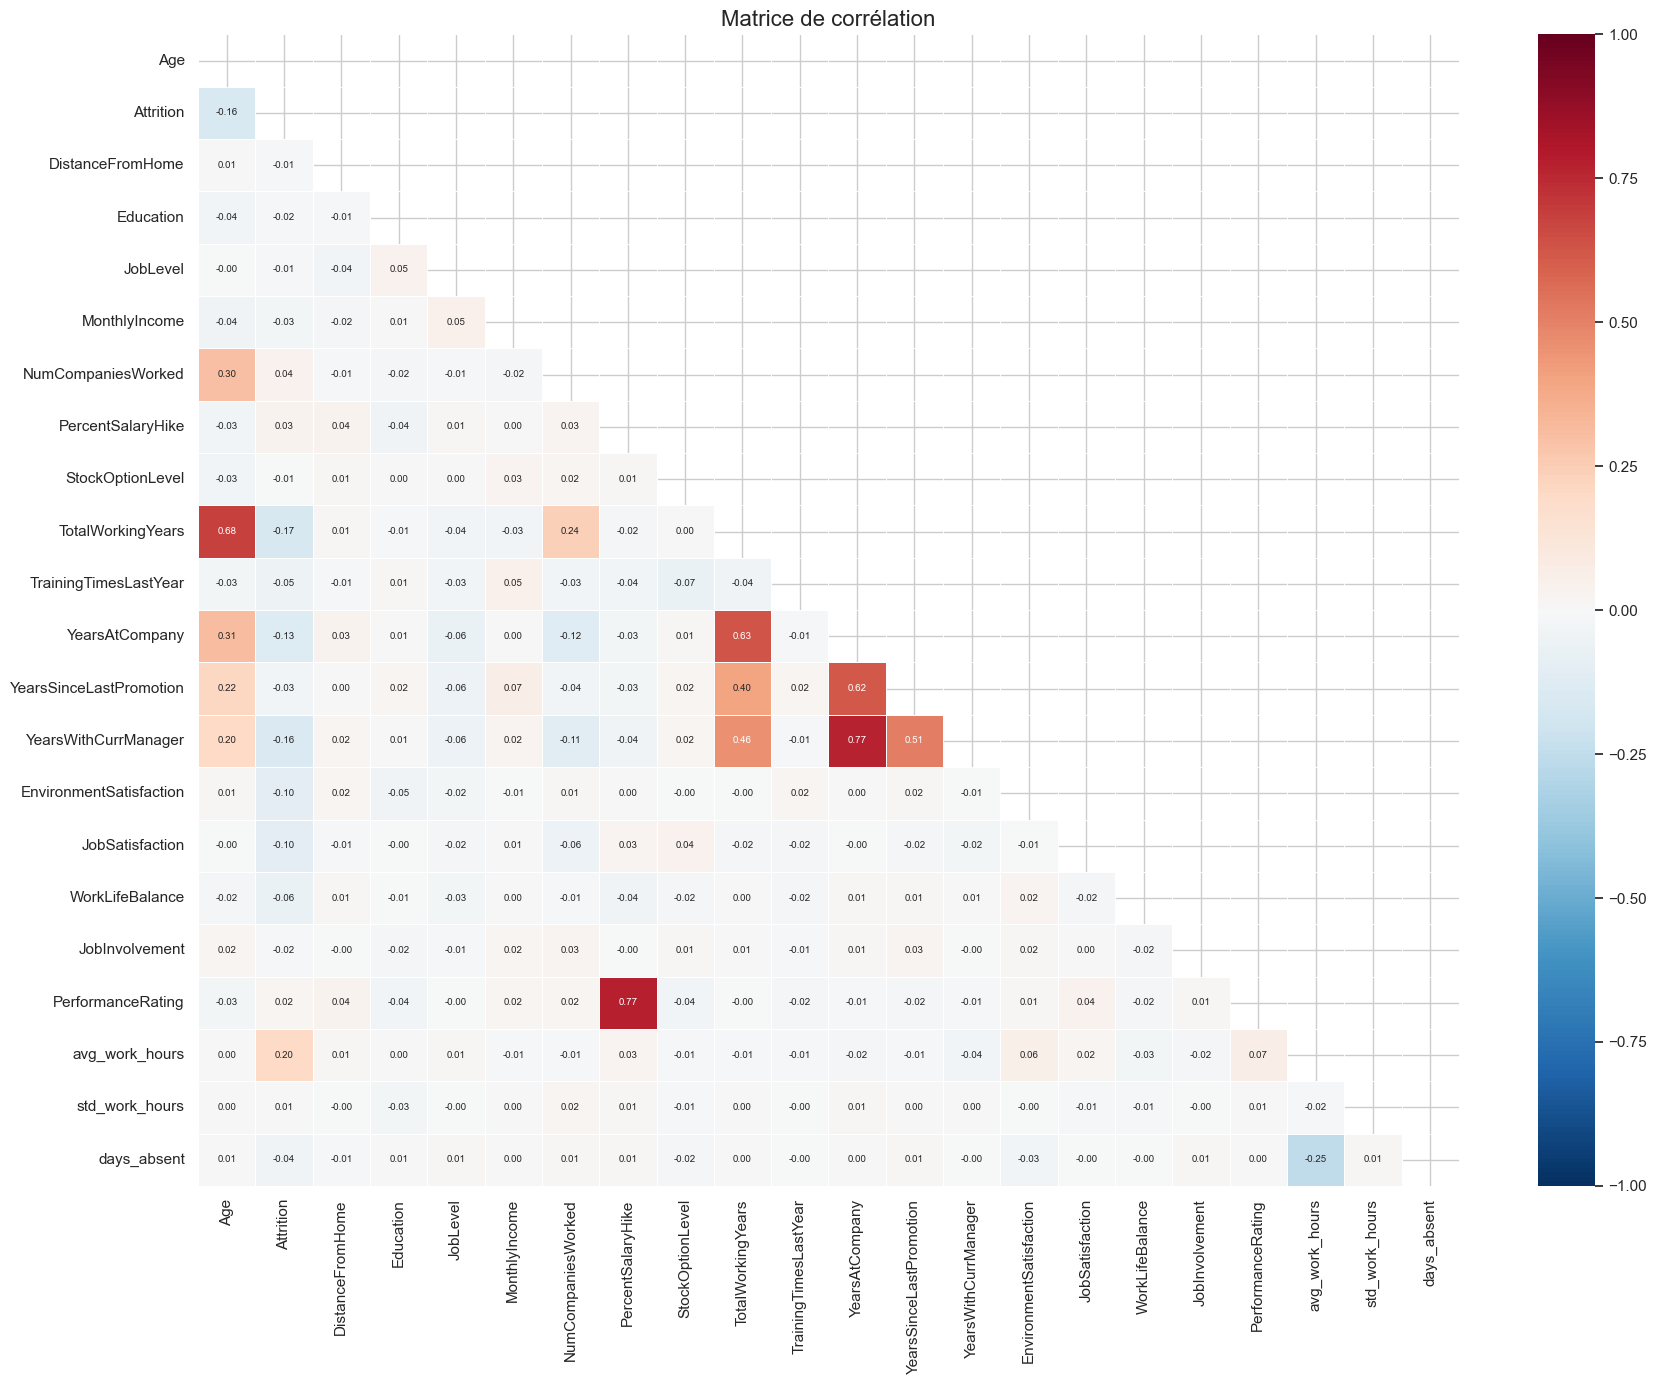

In [14]:
# Matrice de corrélation
plt.figure(figsize=(18, 14))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Matrice de corrélation', fontsize=16)
plt.tight_layout()
plt.show()

### Top corrélations avec Attrition

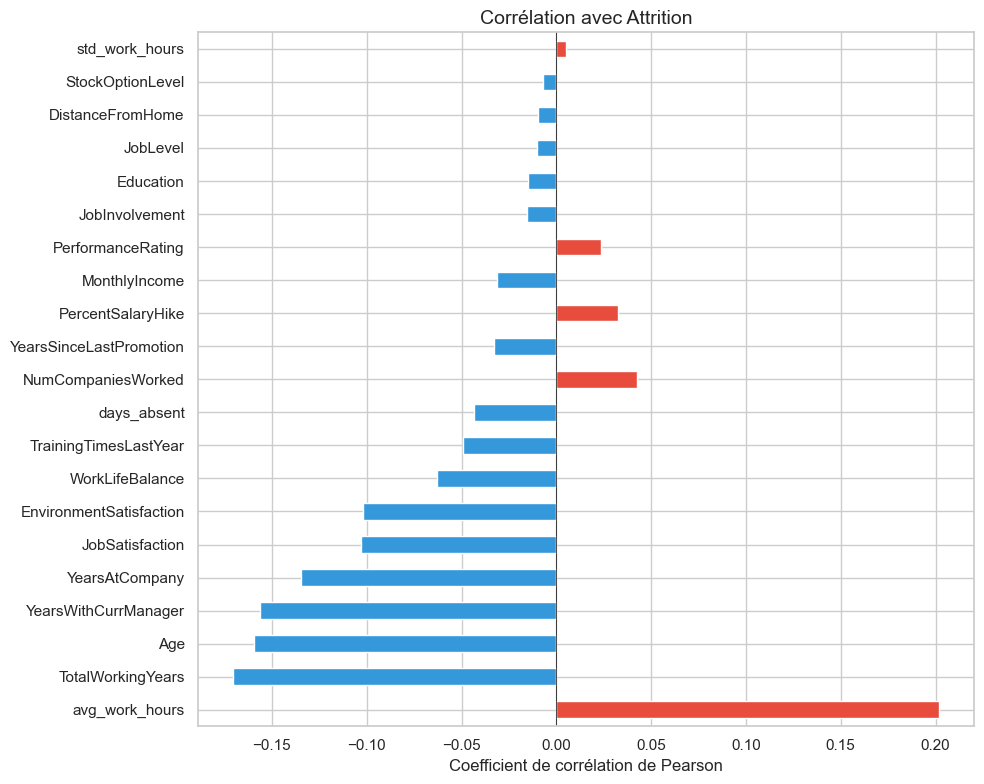


Top 10 corrélations (valeur absolue) :
avg_work_hours             0.201688
TotalWorkingYears         -0.170338
Age                       -0.159205
YearsWithCurrManager      -0.156199
YearsAtCompany            -0.134392
JobSatisfaction           -0.102847
EnvironmentSatisfaction   -0.102142
WorkLifeBalance           -0.062756
TrainingTimesLastYear     -0.049431
days_absent               -0.043517


In [15]:
# Corrélations avec la cible
corr_attrition = corr_matrix['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_attrition.values]
corr_attrition.plot(kind='barh', color=colors)
plt.title('Corrélation avec Attrition', fontsize=14)
plt.xlabel('Coefficient de corrélation de Pearson')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop 10 corrélations (valeur absolue) :")
print(corr_attrition.head(10).to_string())

### Boxplots — Variables numériques vs Attrition

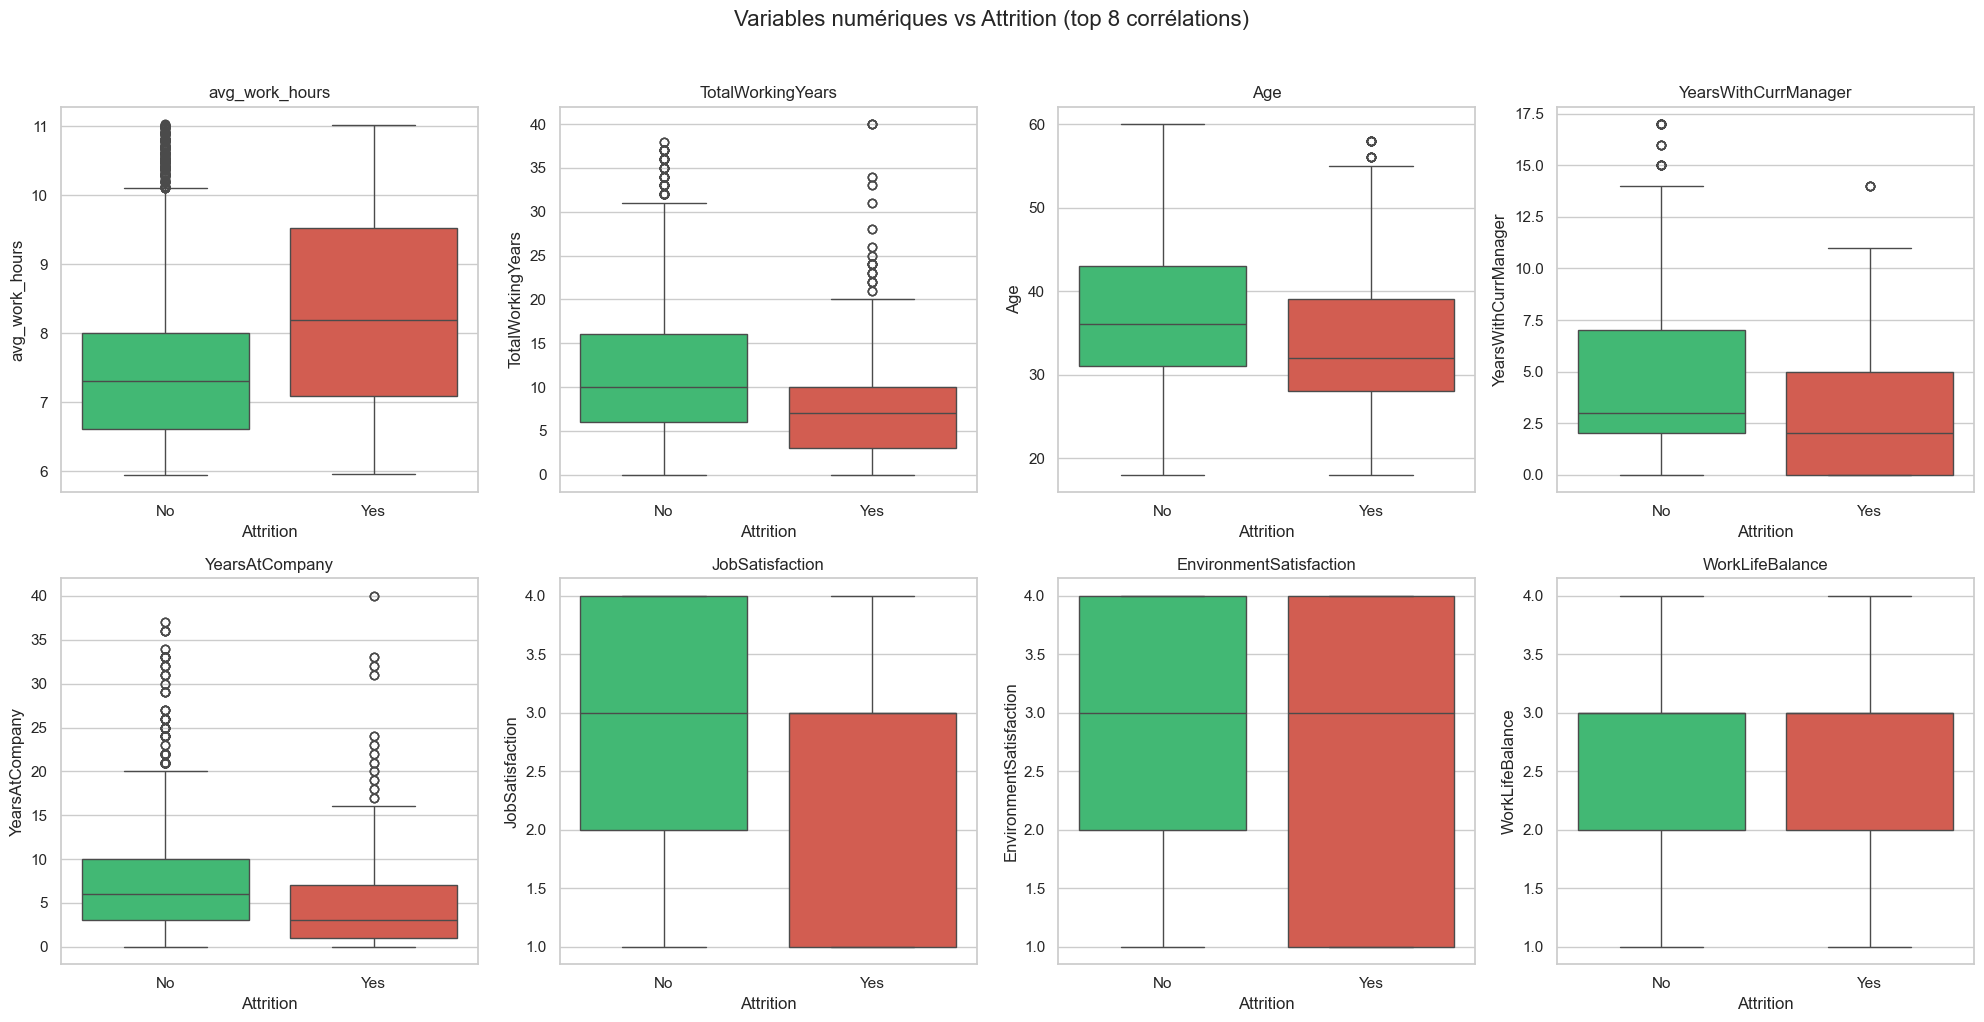

In [16]:
# Top variables numériques les plus corrélées avec Attrition
top_num = corr_attrition.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(top_num):
    sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xticklabels(['No', 'Yes'])

plt.suptitle('Variables numériques vs Attrition (top 8 corrélations)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Variables catégorielles vs Attrition

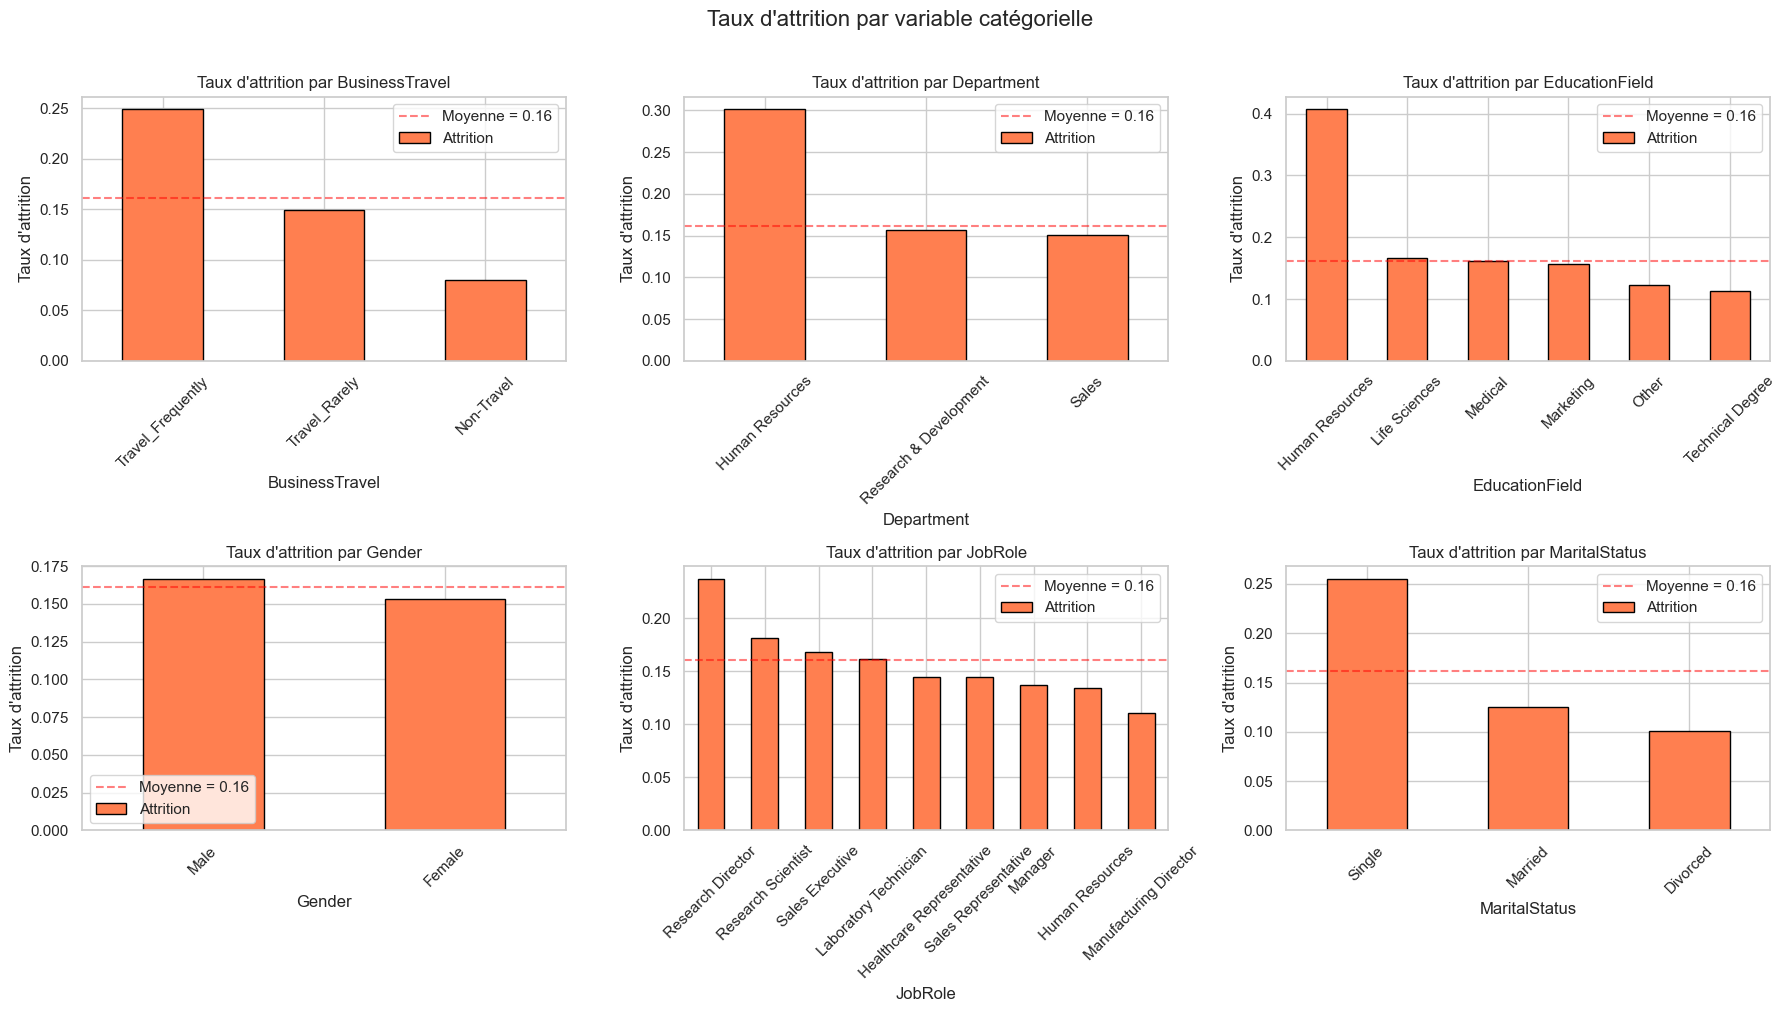

In [17]:
if len(cat_cols) > 0:
    n_cols_plot = 3
    n_rows_plot = (len(cat_cols) + n_cols_plot - 1) // n_cols_plot
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        # Taux d'attrition par catégorie
        attrition_rate = df.groupby(col)['Attrition'].mean().sort_values(ascending=False)
        attrition_rate.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
        axes[i].set_title(f'Taux d\'attrition par {col}', fontsize=12)
        axes[i].set_ylabel('Taux d\'attrition')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].axhline(y=df['Attrition'].mean(), color='red', linestyle='--', alpha=0.5,
                        label=f'Moyenne = {df["Attrition"].mean():.2f}')
        axes[i].legend()

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Taux d\'attrition par variable catégorielle', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

## 1.10 Synthèse EDA

**Observations clés** :
- Le dataset est **déséquilibré** (~84% No vs ~16% Yes) → nécessite `class_weight='balanced'` en classification
- Les variables les plus corrélées avec l'attrition sont typiquement : TotalWorkingYears, YearsAtCompany, Age, MonthlyIncome (négativement), et avg_work_hours
- Les features issues de in_time/out_time apportent de l'information supplémentaire (heures travaillées, régularité)
- Peu de valeurs manquantes dans l'ensemble

---

# Partie 2 — Régression

> Inspiré du Workshop « Régression »

**Objectif** : Prédire le **MonthlyIncome** des employés à partir de leurs caractéristiques.  
On compare plusieurs approches : équation normale, statsmodels, sklearn (LinearRegression, DecisionTree, RandomForest, GradientBoosting, KNN, SVR).

## 2.1 Préparation des données pour la régression

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Variable cible pour la régression
target_reg = 'MonthlyIncome'

# Séparer features et cible
X_reg = df.drop(columns=[target_reg])
y_reg = df[target_reg].copy()

# Identifier les types de colonnes
num_features = X_reg.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_reg.select_dtypes(include=['object']).columns.tolist()

print(f"Features numériques ({len(num_features)}) : {num_features}")
print(f"Features catégorielles ({len(cat_features)}) : {cat_features}")
print(f"Cible : {target_reg}")
print(f"Shape X: {X_reg.shape}, Shape y: {y_reg.shape}")

Features numériques (21) : ['Age', 'Attrition', 'DistanceFromHome', 'Education', 'JobLevel', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_work_hours', 'std_work_hours', 'days_absent']
Features catégorielles (6) : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
Cible : MonthlyIncome
Shape X: (4410, 27), Shape y: (4410,)


In [19]:
# Pipelines de prétraitement
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Split train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Prétraiter
X_train_processed = preprocessor.fit_transform(X_train_reg)
X_test_processed = preprocessor.transform(X_test_reg)

print(f"X_train transformé : {X_train_processed.shape}")
print(f"X_test transformé  : {X_test_processed.shape}")

X_train transformé : (3528, 47)
X_test transformé  : (882, 47)


## 2.2 Équation normale (OLS)

La solution analytique de la régression linéaire : $\hat{\theta} = (X^T X)^{-1} X^T y$

In [20]:
# Ajout du biais (colonne de 1)
X_b_train = np.c_[np.ones((X_train_processed.shape[0], 1)), X_train_processed]
X_b_test = np.c_[np.ones((X_test_processed.shape[0], 1)), X_test_processed]

# Équation normale
theta_best = np.linalg.pinv(X_b_train.T @ X_b_train) @ X_b_train.T @ y_train_reg.values

# Prédictions
y_pred_normal = X_b_test @ theta_best

# Métriques
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse_normal = mean_squared_error(y_test_reg, y_pred_normal)
rmse_normal = np.sqrt(mse_normal)
r2_normal = r2_score(y_test_reg, y_pred_normal)
mae_normal = mean_absolute_error(y_test_reg, y_pred_normal)

print("=== Équation Normale ===")
print(f"MSE  : {mse_normal:,.0f}")
print(f"RMSE : {rmse_normal:,.0f}")
print(f"MAE  : {mae_normal:,.0f}")
print(f"R²   : {r2_normal:.4f}")

=== Équation Normale ===
MSE  : 2,228,838,527
RMSE : 47,211
MAE  : 35,771
R²   : 0.0224


## 2.3 Régression avec statsmodels

In [21]:
import statsmodels.api as sm

# Ajouter la constante
X_sm = sm.add_constant(X_train_processed)
model_sm = sm.OLS(y_train_reg.values, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     2.798
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           1.00e-08
Time:                        14:13:11   Log-Likelihood:                -42893.
No. Observations:                3528   AIC:                         8.587e+04
Df Residuals:                    3486   BIC:                         8.613e+04
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.238e+04    654.297     34.209      0.0

In [22]:
# Prédictions statsmodels
X_sm_test = sm.add_constant(X_test_processed)
y_pred_sm = model_sm.predict(X_sm_test)

mse_sm = mean_squared_error(y_test_reg, y_pred_sm)
r2_sm = r2_score(y_test_reg, y_pred_sm)
print(f"\nstatsmodels OLS — MSE: {mse_sm:,.0f} | R²: {r2_sm:.4f}")


statsmodels OLS — MSE: 2,228,838,527 | R²: 0.0224


## 2.4 sklearn — Comparaison de modèles de régression

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import time

# Dictionnaire des modèles
reg_models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'SVR (RBF)': SVR(kernel='rbf'),
}

reg_results = {}

for name, model in reg_models.items():
    start = time.time()
    model.fit(X_train_processed, y_train_reg)
    train_time = time.time() - start
    
    y_pred_train = model.predict(X_train_processed)
    y_pred_test = model.predict(X_test_processed)
    
    reg_results[name] = {
        'MSE_train': mean_squared_error(y_train_reg, y_pred_train),
        'MSE_test': mean_squared_error(y_test_reg, y_pred_test),
        'RMSE_test': np.sqrt(mean_squared_error(y_test_reg, y_pred_test)),
        'MAE_test': mean_absolute_error(y_test_reg, y_pred_test),
        'R2_train': r2_score(y_train_reg, y_pred_train),
        'R2_test': r2_score(y_test_reg, y_pred_test),
        'Training_time': train_time
    }
    
    print(f"{name:25s} | R² train: {reg_results[name]['R2_train']:.4f} | "
          f"R² test: {reg_results[name]['R2_test']:.4f} | "
          f"RMSE: {reg_results[name]['RMSE_test']:,.0f} | "
          f"Time: {train_time:.3f}s")

LinearRegression          | R² train: 0.0319 | R² test: 0.0224 | RMSE: 47,211 | Time: 0.041s
DecisionTree              | R² train: 1.0000 | R² test: 0.8968 | RMSE: 15,341 | Time: 0.075s
RandomForest              | R² train: 0.9719 | R² test: 0.7960 | RMSE: 21,567 | Time: 0.557s
GradientBoosting          | R² train: 0.3196 | R² test: 0.2083 | RMSE: 42,487 | Time: 0.740s
KNN (k=5)                 | R² train: 0.6063 | R² test: 0.2801 | RMSE: 40,513 | Time: 0.001s
SVR (RBF)                 | R² train: -0.1136 | R² test: -0.1614 | RMSE: 51,458 | Time: 0.687s


## 2.5 Validation croisée

In [24]:
print("Validation croisée (5-fold) sur l'ensemble d'entraînement :\n")

cv_results = {}
for name, model_class in [
    ('LinearRegression', LinearRegression()),
    ('DecisionTree', DecisionTreeRegressor(random_state=42)),
    ('RandomForest', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('GradientBoosting', GradientBoostingRegressor(n_estimators=100, random_state=42)),
]:
    scores = cross_val_score(model_class, X_train_processed, y_train_reg,
                             cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} | R² moyen: {scores.mean():.4f} ± {scores.std():.4f} | "
          f"Scores: [{', '.join(f'{s:.4f}' for s in scores)}]")

Validation croisée (5-fold) sur l'ensemble d'entraînement :

LinearRegression          | R² moyen: 0.0004 ± 0.0124 | Scores: [0.0013, -0.0121, -0.0150, 0.0107, 0.0170]
DecisionTree              | R² moyen: 0.5765 ± 0.0163 | Scores: [0.5748, 0.5836, 0.5695, 0.5526, 0.6020]
RandomForest              | R² moyen: 0.6807 ± 0.0227 | Scores: [0.6970, 0.6613, 0.6479, 0.6884, 0.7089]
GradientBoosting          | R² moyen: 0.1810 ± 0.0272 | Scores: [0.2026, 0.1436, 0.1522, 0.2053, 0.2010]


## 2.6 Visualisation des résultats de régression

In [25]:
# Tableau comparatif
reg_df = pd.DataFrame(reg_results).T
reg_df = reg_df.sort_values('R2_test', ascending=False)

print("\n=== Tableau comparatif des modèles de régression ===\n")
print(reg_df[['R2_train', 'R2_test', 'RMSE_test', 'MAE_test', 'Training_time']].to_string())

# Détection overfitting
reg_df['Overfit_gap'] = reg_df['R2_train'] - reg_df['R2_test']
print("\n--- Détection d'overfitting ---")
for idx, row in reg_df.iterrows():
    status = "⚠️ OVERFITTING" if row['Overfit_gap'] > 0.1 else "✓ OK"
    print(f"{idx:25s} | Gap R²: {row['Overfit_gap']:.4f} | {status}")


=== Tableau comparatif des modèles de régression ===

                  R2_train   R2_test     RMSE_test      MAE_test  Training_time
DecisionTree      1.000000  0.896778  15340.780305   2987.868481       0.075096
RandomForest      0.971911  0.795987  21567.066839  14589.285374       0.556963
KNN (k=5)         0.606263  0.280099  40513.379069  30046.476190       0.000596
GradientBoosting  0.319649  0.208267  42486.568611  32220.170964       0.740006
LinearRegression  0.031859  0.022416  47210.576430  35770.756298       0.040797
SVR (RBF)        -0.113590 -0.161396  51457.937581  34743.532762       0.687163

--- Détection d'overfitting ---
DecisionTree              | Gap R²: 0.1032 | ⚠️ OVERFITTING
RandomForest              | Gap R²: 0.1759 | ⚠️ OVERFITTING
KNN (k=5)                 | Gap R²: 0.3262 | ⚠️ OVERFITTING
GradientBoosting          | Gap R²: 0.1114 | ⚠️ OVERFITTING
LinearRegression          | Gap R²: 0.0094 | ✓ OK
SVR (RBF)                 | Gap R²: 0.0478 | ✓ OK


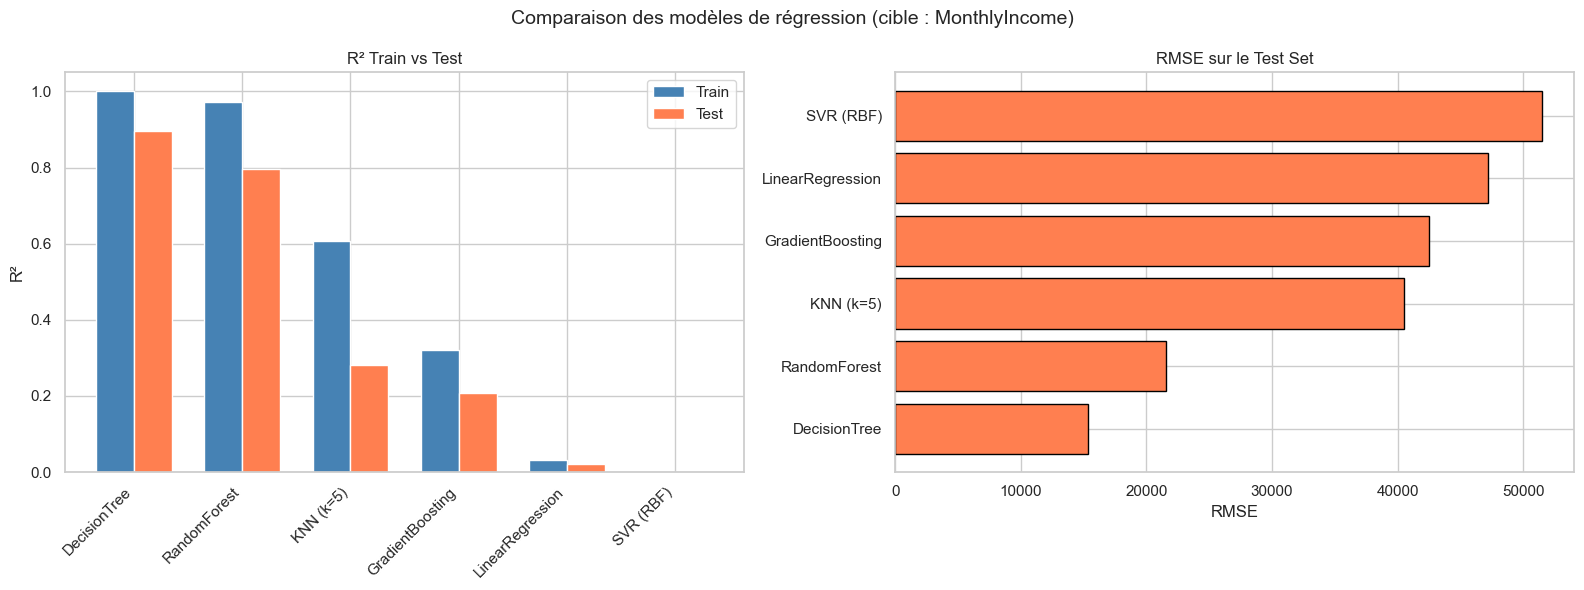

In [26]:
# Graphique comparatif R²
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² comparaison train vs test
x = np.arange(len(reg_df))
width = 0.35
axes[0].bar(x - width/2, reg_df['R2_train'], width, label='Train', color='steelblue')
axes[0].bar(x + width/2, reg_df['R2_test'], width, label='Test', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(reg_df.index, rotation=45, ha='right')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Train vs Test')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# RMSE comparaison
axes[1].barh(reg_df.index, reg_df['RMSE_test'], color='coral', edgecolor='black')
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE sur le Test Set')

plt.suptitle('Comparaison des modèles de régression (cible : MonthlyIncome)', fontsize=14)
plt.tight_layout()
plt.show()

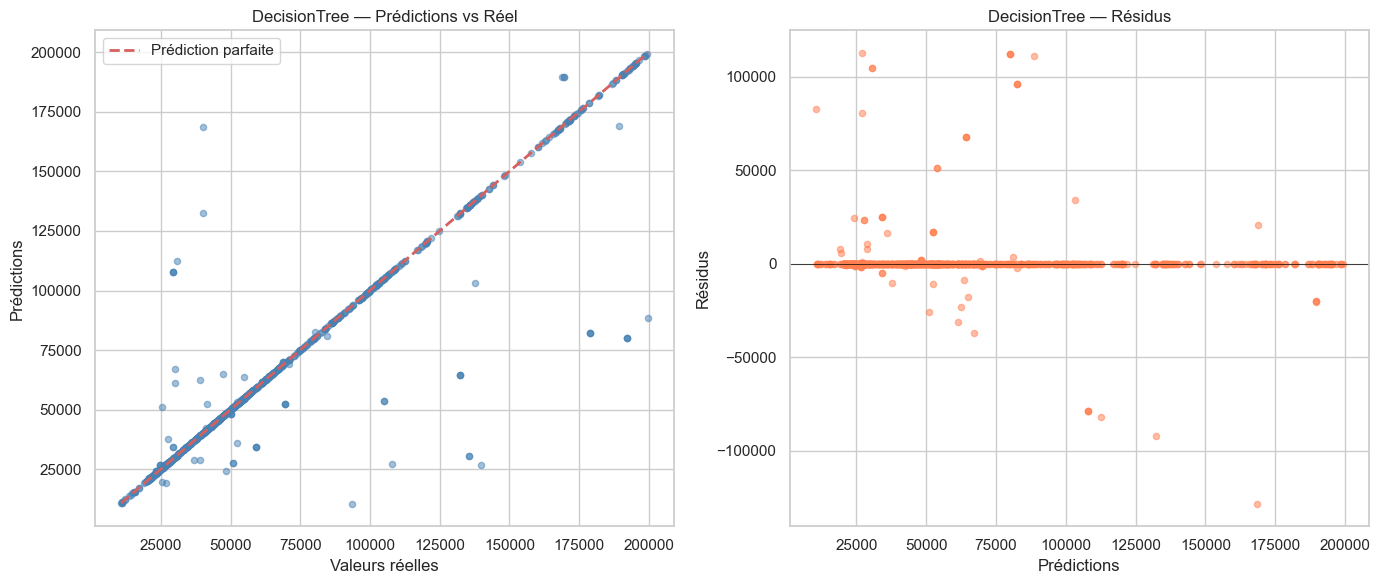

In [27]:
# Prédictions vs valeurs réelles (meilleur modèle)
best_reg_name = reg_df.index[0]
best_reg_model = reg_models[best_reg_name]
y_pred_best = best_reg_model.predict(X_test_processed)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(y_test_reg, y_pred_best, alpha=0.5, s=20, color='steelblue')
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()],
             'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Prédictions')
axes[0].set_title(f'{best_reg_name} — Prédictions vs Réel')
axes[0].legend()

# Résidus
residuals = y_test_reg.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=20, color='coral')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Prédictions')
axes[1].set_ylabel('Résidus')
axes[1].set_title(f'{best_reg_name} — Résidus')

plt.tight_layout()
plt.show()

## 2.7 Synthèse Régression

**Observations** :
- La régression linéaire fournit un baseline solide pour prédire le MonthlyIncome
- Les modèles ensemblistes (RandomForest, GradientBoosting) offrent généralement de meilleures performances
- Le DecisionTree tend à overfitter (R² train ≈ 1.0 vs R² test plus bas)
- La validation croisée confirme la stabilité des modèles

---

# Partie 3 — Classification

> Inspiré du Workshop « Classification »

**Objectif** : Prédire le départ des employés (`Attrition` : 0/1).  
On compare 8 classifieurs avec gestion du déséquilibre de classes.

## 3.1 Préparation des données pour la classification

In [28]:
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve, average_precision_score)

# Variable cible pour la classification
target_clf = 'Attrition'

X_clf = df.drop(columns=[target_clf])
y_clf = df[target_clf].copy()

# Identifier colonnes
num_features_clf = X_clf.select_dtypes(include=[np.number]).columns.tolist()
cat_features_clf = X_clf.select_dtypes(include=['object']).columns.tolist()

# Preprocesseur
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features_clf),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_features_clf)
    ]
)

# Split stratifié
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Prétraiter
X_train_clf_proc = preprocessor_clf.fit_transform(X_train_clf)
X_test_clf_proc = preprocessor_clf.transform(X_test_clf)

print(f"Distribution cible (train) : {dict(pd.Series(y_train_clf).value_counts())}")
print(f"Distribution cible (test)  : {dict(pd.Series(y_test_clf).value_counts())}")
print(f"X_train: {X_train_clf_proc.shape} | X_test: {X_test_clf_proc.shape}")

Distribution cible (train) : {0: np.int64(2959), 1: np.int64(569)}
Distribution cible (test)  : {0: np.int64(740), 1: np.int64(142)}
X_train: (3528, 47) | X_test: (882, 47)


## 3.2 Entraînement des classifieurs

In [29]:
# Dictionnaire des classifieurs
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Perceptron': Perceptron(
        max_iter=1000, random_state=42),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42),
}

clf_results = {}

for name, clf in classifiers.items():
    start = time.time()
    clf.fit(X_train_clf_proc, y_train_clf)
    train_time = time.time() - start
    
    y_pred = clf.predict(X_test_clf_proc)
    
    # Probabilités (si disponibles)
    if hasattr(clf, 'predict_proba'):
        y_proba = clf.predict_proba(X_test_clf_proc)[:, 1]
        auc = roc_auc_score(y_test_clf, y_proba)
    elif hasattr(clf, 'decision_function'):
        y_scores = clf.decision_function(X_test_clf_proc)
        auc = roc_auc_score(y_test_clf, y_scores)
    else:
        auc = np.nan
        y_proba = None
    
    clf_results[name] = {
        'Accuracy': accuracy_score(y_test_clf, y_pred),
        'Precision': precision_score(y_test_clf, y_pred, zero_division=0),
        'Recall': recall_score(y_test_clf, y_pred, zero_division=0),
        'F1': f1_score(y_test_clf, y_pred, zero_division=0),
        'AUC-ROC': auc,
        'Training_time': train_time,
        'y_pred': y_pred,
    }
    
    print(f"{name:25s} | Acc: {clf_results[name]['Accuracy']:.4f} | "
          f"Prec: {clf_results[name]['Precision']:.4f} | "
          f"Rec: {clf_results[name]['Recall']:.4f} | "
          f"F1: {clf_results[name]['F1']:.4f} | "
          f"AUC: {clf_results[name]['AUC-ROC']:.4f}" if not np.isnan(auc) else
          f"{name:25s} | Acc: {clf_results[name]['Accuracy']:.4f} | "
          f"Prec: {clf_results[name]['Precision']:.4f} | "
          f"Rec: {clf_results[name]['Recall']:.4f} | "
          f"F1: {clf_results[name]['F1']:.4f} | "
          f"AUC: N/A")

Logistic Regression       | Acc: 0.7755 | Prec: 0.3931 | Rec: 0.7254 | F1: 0.5099 | AUC: 0.8101
Perceptron                | Acc: 0.8107 | Prec: 0.3684 | Rec: 0.2465 | F1: 0.2954 | AUC: 0.6669
SVM (RBF)                 | Acc: 0.9229 | Prec: 0.7284 | Rec: 0.8310 | F1: 0.7763 | AUC: 0.9642
Naive Bayes               | Acc: 0.8299 | Prec: 0.4661 | Rec: 0.3873 | F1: 0.4231 | AUC: 0.7674
KNN (k=5)                 | Acc: 0.8605 | Prec: 0.6301 | Rec: 0.3239 | F1: 0.4279 | AUC: 0.9111
Decision Tree             | Acc: 0.9841 | Prec: 0.9571 | Rec: 0.9437 | F1: 0.9504 | AUC: 0.9678
Random Forest             | Acc: 0.9807 | Prec: 1.0000 | Rec: 0.8803 | F1: 0.9363 | AUC: 0.9979
Gradient Boosting         | Acc: 0.8934 | Prec: 0.8529 | Rec: 0.4085 | F1: 0.5524 | AUC: 0.9096


## 3.3 Rapports de classification détaillés

In [30]:
for name in classifiers:
    print(f"\n{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    print(classification_report(y_test_clf, clf_results[name]['y_pred'],
                                target_names=['No (0)', 'Yes (1)']))


 Logistic Regression
              precision    recall  f1-score   support

      No (0)       0.94      0.79      0.85       740
     Yes (1)       0.39      0.73      0.51       142

    accuracy                           0.78       882
   macro avg       0.67      0.76      0.68       882
weighted avg       0.85      0.78      0.80       882


 Perceptron
              precision    recall  f1-score   support

      No (0)       0.86      0.92      0.89       740
     Yes (1)       0.37      0.25      0.30       142

    accuracy                           0.81       882
   macro avg       0.62      0.58      0.59       882
weighted avg       0.78      0.81      0.79       882


 SVM (RBF)
              precision    recall  f1-score   support

      No (0)       0.97      0.94      0.95       740
     Yes (1)       0.73      0.83      0.78       142

    accuracy                           0.92       882
   macro avg       0.85      0.89      0.86       882
weighted avg       0.93    

# Partie 4 — Analyse Comparative et Recommandations

## 4.1 Tableau comparatif global

In [31]:
# Créer le DataFrame de résultats (sans y_pred)
results_display = {name: {k: v for k, v in m.items() if k != 'y_pred'}
                   for name, m in clf_results.items()}
clf_df = pd.DataFrame(results_display).T
clf_df = clf_df.sort_values('F1', ascending=False)

# Affichage formaté
print("=== Tableau comparatif des classifieurs ===\n")
display_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'Training_time']
print(clf_df[display_cols].to_string(float_format=lambda x: f'{x:.4f}'))

print(f"\n🏆 Meilleur F1-Score : {clf_df.index[0]} ({clf_df['F1'].iloc[0]:.4f})")

=== Tableau comparatif des classifieurs ===

                     Accuracy  Precision  Recall     F1  AUC-ROC  Training_time
Decision Tree          0.9841     0.9571  0.9437 0.9504   0.9678         0.0347
Random Forest          0.9807     1.0000  0.8803 0.9363   0.9979         0.3294
SVM (RBF)              0.9229     0.7284  0.8310 0.7763   0.9642         2.3852
Gradient Boosting      0.8934     0.8529  0.4085 0.5524   0.9096         1.1554
Logistic Regression    0.7755     0.3931  0.7254 0.5099   0.8101         0.0257
KNN (k=5)              0.8605     0.6301  0.3239 0.4279   0.9111         0.0007
Naive Bayes            0.8299     0.4661  0.3873 0.4231   0.7674         0.0030
Perceptron             0.8107     0.3684  0.2465 0.2954   0.6669         0.0068

🏆 Meilleur F1-Score : Decision Tree (0.9504)


## 4.2 Matrices de confusion

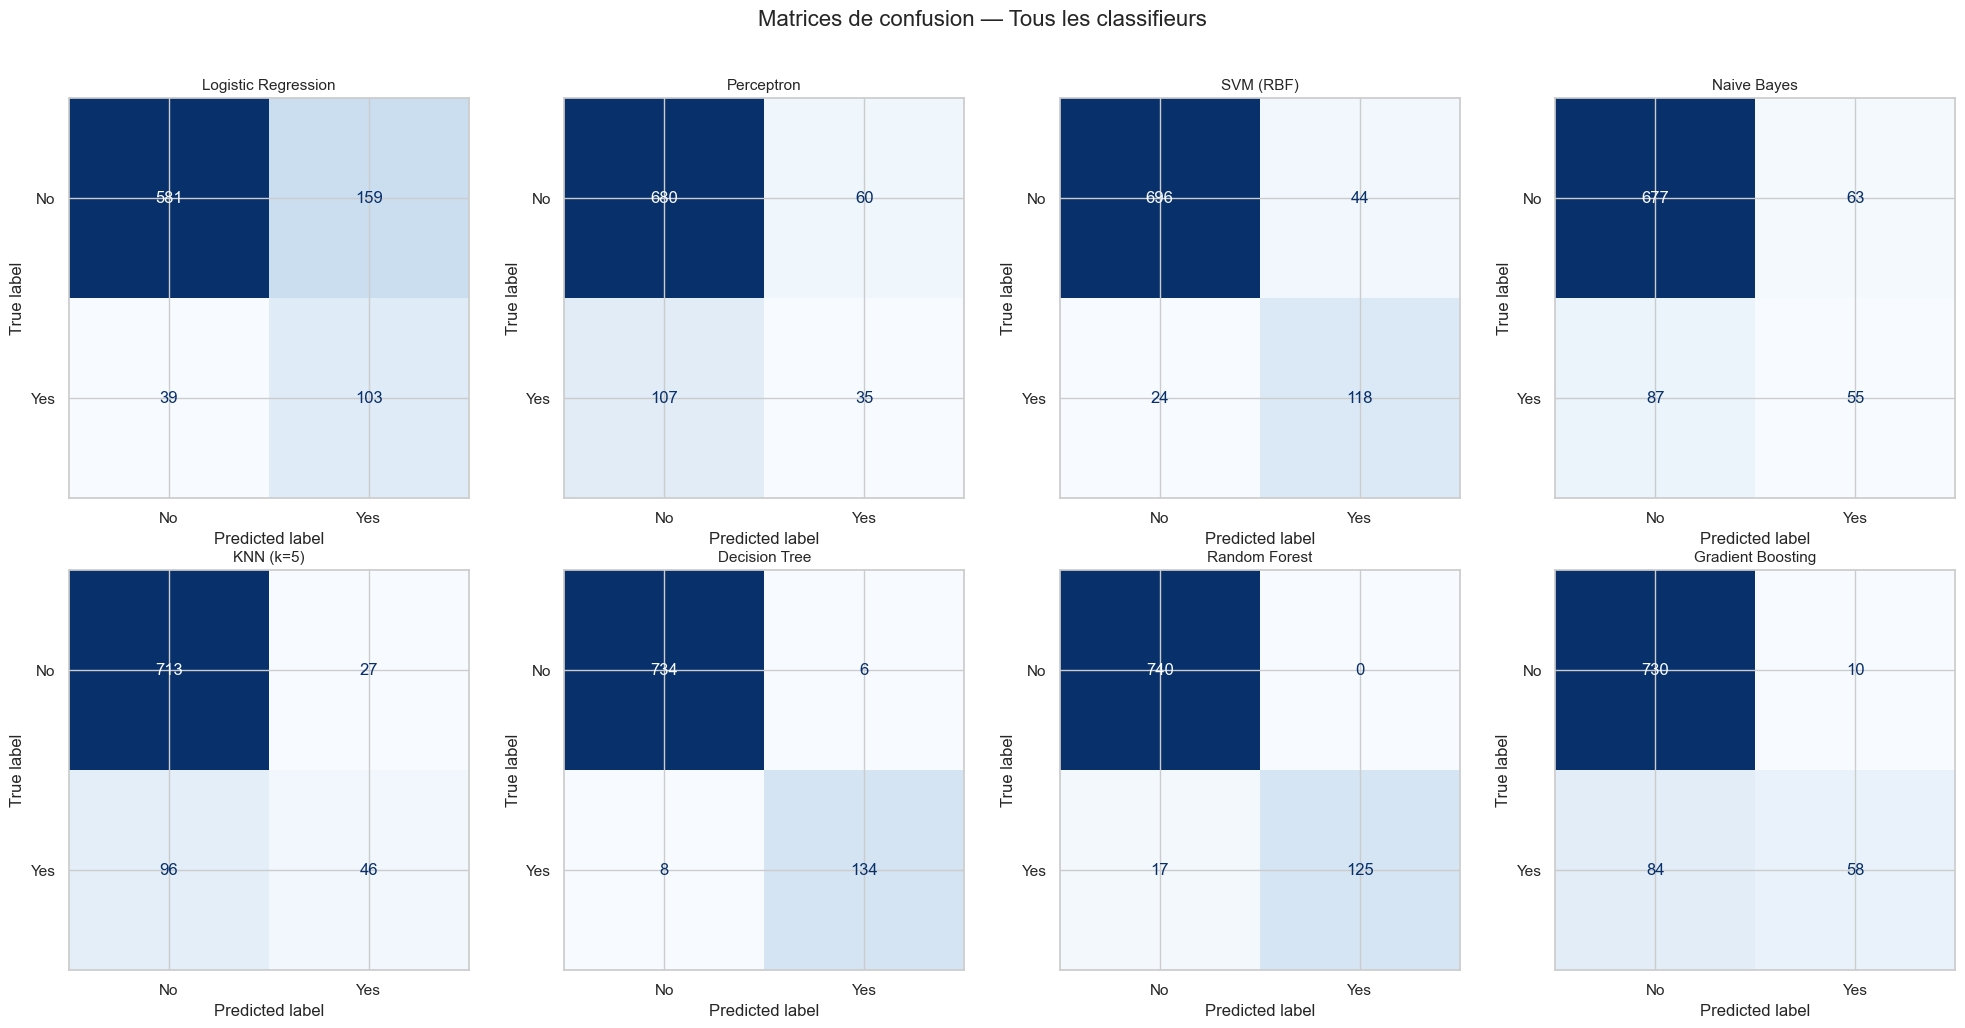

In [32]:
n_models = len(classifiers)
n_cols_cm = 4
n_rows_cm = (n_models + n_cols_cm - 1) // n_cols_cm

fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(20, 5 * n_rows_cm))
axes = axes.flatten()

for i, (name, clf) in enumerate(classifiers.items()):
    cm = confusion_matrix(y_test_clf, clf_results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de confusion — Tous les classifieurs', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4.3 Courbes ROC

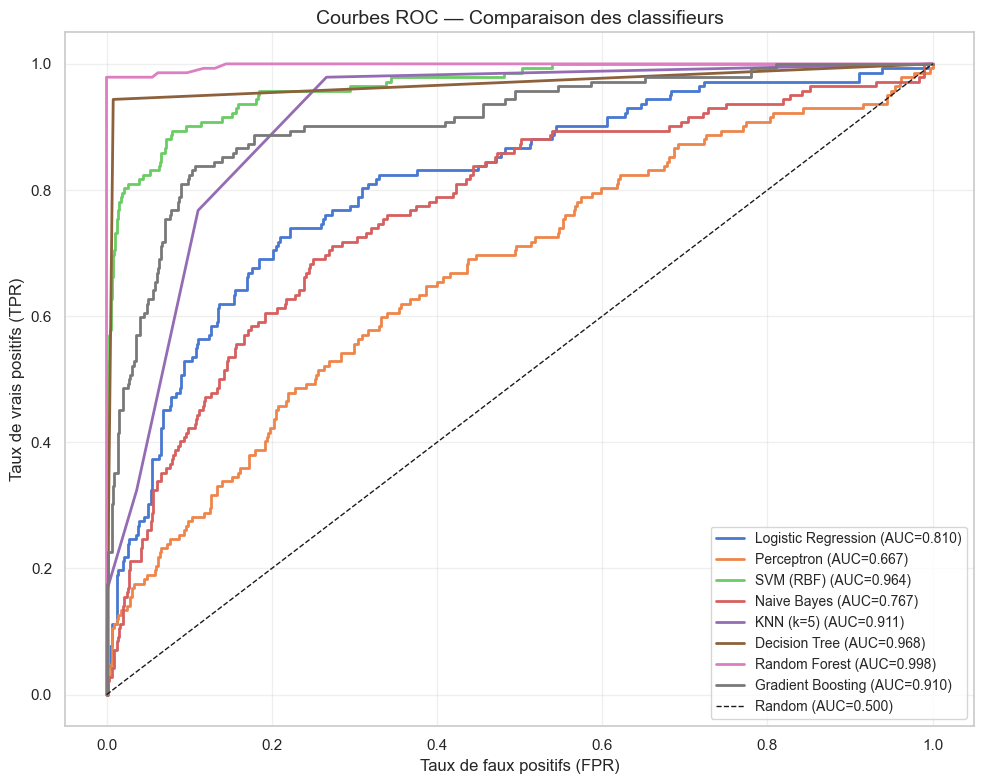

In [33]:
plt.figure(figsize=(10, 8))

for name, clf in classifiers.items():
    if hasattr(clf, 'predict_proba'):
        y_proba = clf.predict_proba(X_test_clf_proc)[:, 1]
    elif hasattr(clf, 'decision_function'):
        y_proba = clf.decision_function(X_test_clf_proc)
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
    auc_val = roc_auc_score(y_test_clf, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
plt.xlabel('Taux de faux positifs (FPR)', fontsize=12)
plt.ylabel('Taux de vrais positifs (TPR)', fontsize=12)
plt.title('Courbes ROC — Comparaison des classifieurs', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.4 Courbes Precision-Recall

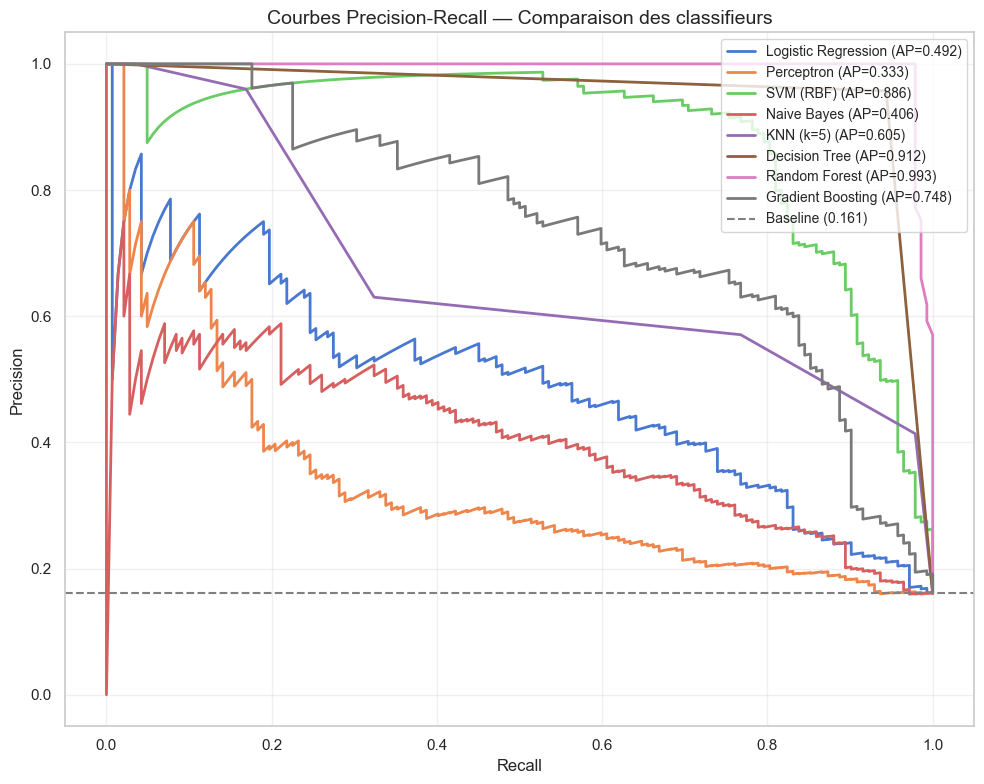

In [34]:
plt.figure(figsize=(10, 8))

for name, clf in classifiers.items():
    if hasattr(clf, 'predict_proba'):
        y_proba = clf.predict_proba(X_test_clf_proc)[:, 1]
    elif hasattr(clf, 'decision_function'):
        y_proba = clf.decision_function(X_test_clf_proc)
    else:
        continue
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_clf, y_proba)
    ap = average_precision_score(y_test_clf, y_proba)
    plt.plot(recall_vals, precision_vals, label=f'{name} (AP={ap:.3f})', linewidth=2)

baseline = y_test_clf.mean()
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Courbes Precision-Recall — Comparaison des classifieurs', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.5 Importance des features

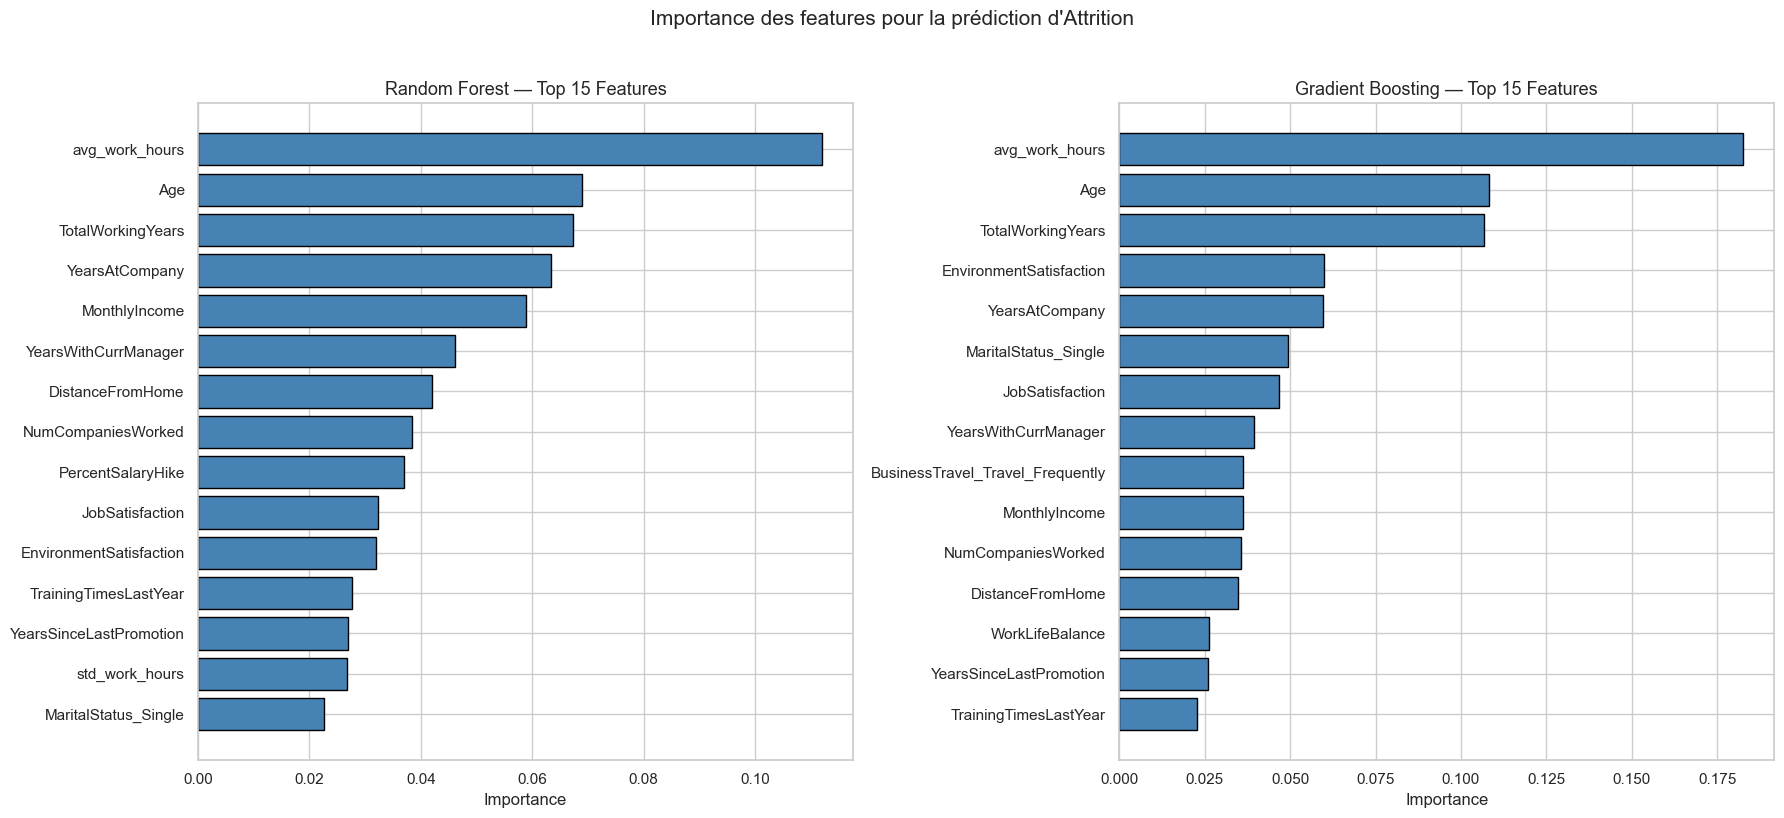

In [35]:
# Feature importance pour RandomForest et GradientBoosting
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Récupérer les noms de features après preprocessing
feature_names = (num_features_clf +
                 list(preprocessor_clf.named_transformers_['cat']
                      .named_steps['encoder']
                      .get_feature_names_out(cat_features_clf)))

for ax, (name, model_key) in zip(axes, [('Random Forest', 'Random Forest'),
                                         ('Gradient Boosting', 'Gradient Boosting')]):
    clf_model = classifiers[model_key]
    importances = clf_model.feature_importances_
    indices = np.argsort(importances)[-15:]  # Top 15
    
    ax.barh(range(len(indices)), importances[indices], color='steelblue', edgecolor='black')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([feature_names[i] for i in indices])
    ax.set_xlabel('Importance')
    ax.set_title(f'{name} — Top 15 Features', fontsize=13)

plt.suptitle('Importance des features pour la prédiction d\'Attrition', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 4.6 Visualisation comparative finale

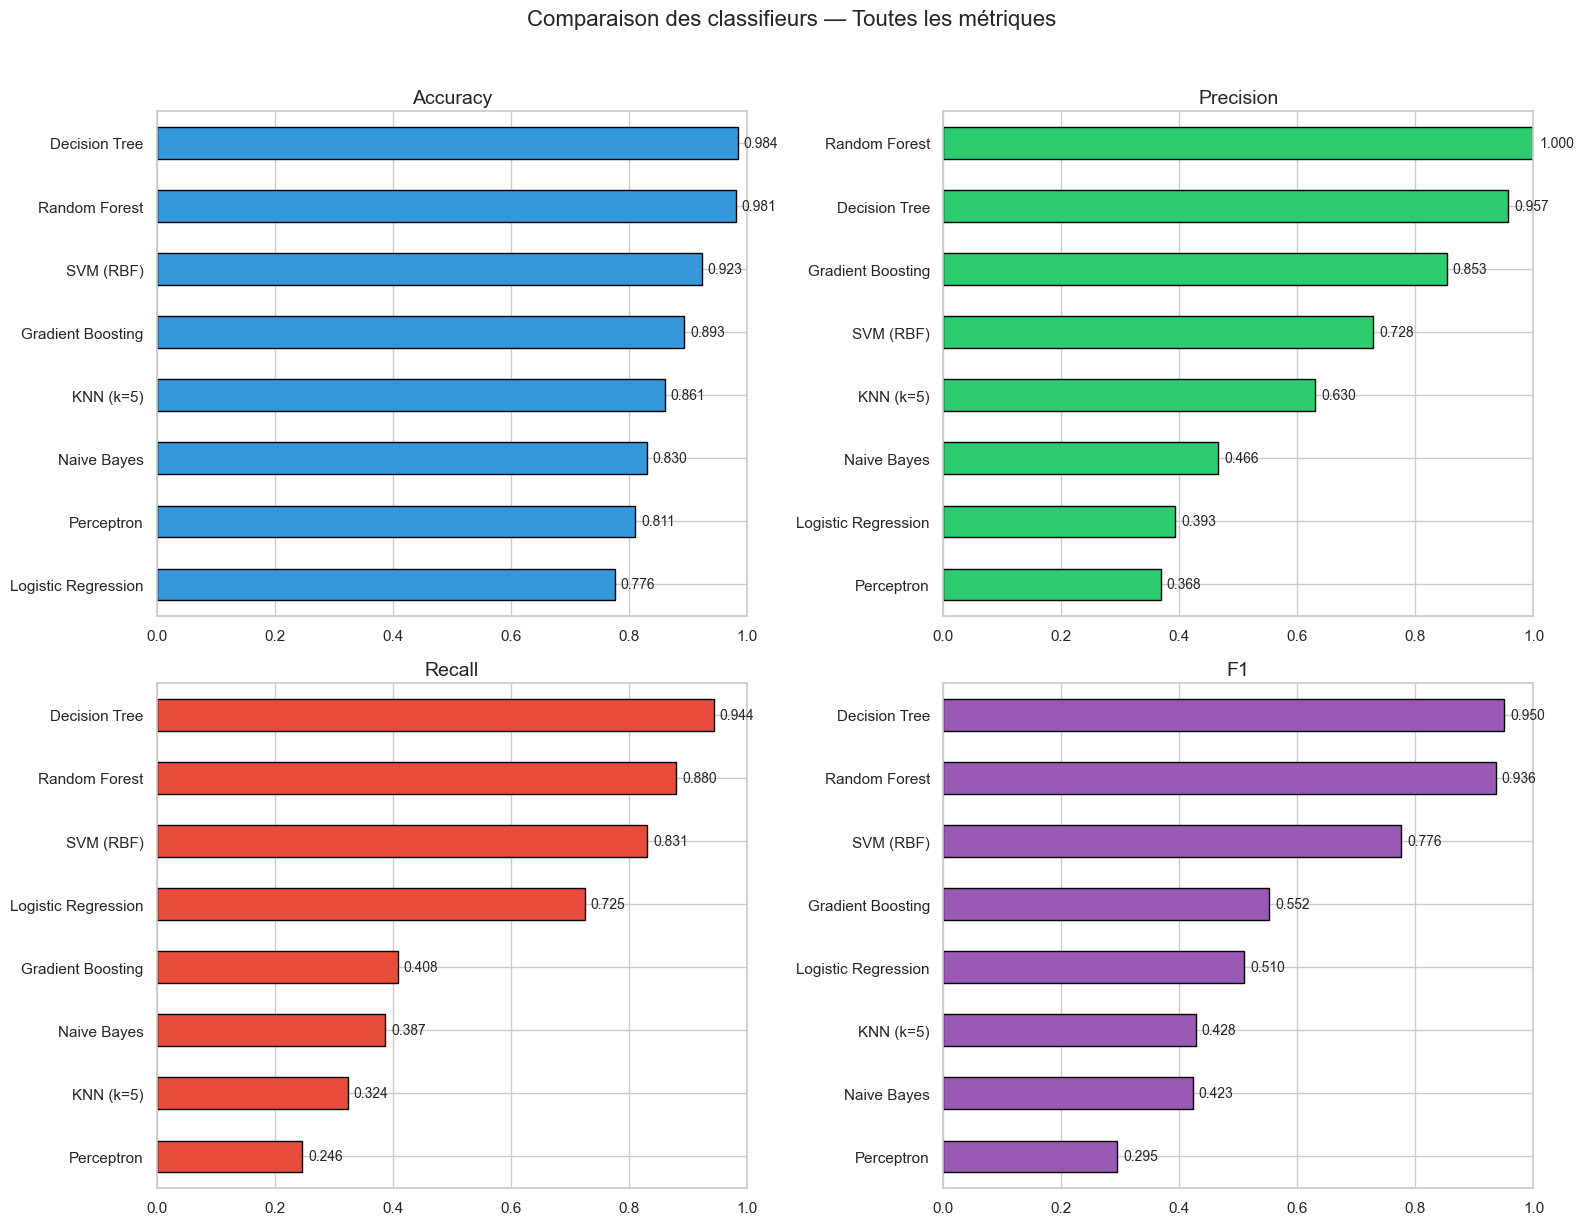

In [36]:
# Bar chart comparatif de toutes les métriques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
colors_metrics = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, metric, color in zip(axes.flatten(), metrics_to_plot, colors_metrics):
    values = clf_df[metric].sort_values(ascending=True)
    values.plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.set_title(metric, fontsize=14)
    ax.set_xlim(0, 1)
    for i, v in enumerate(values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.suptitle('Comparaison des classifieurs — Toutes les métriques', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4.7 Recommandations et Conclusion

### Choix du modèle
Dans le contexte RH de HumanForYou, le **Recall** est la métrique la plus importante :
- Un faux négatif (employé à risque non détecté) a un coût élevé (perte de talent)
- Un faux positif (employé stable signalé) a un coût faible (attention RH supplémentaire)

→ Privilégier le modèle avec le **meilleur Recall** tout en conservant un F1-Score acceptable.

### Leviers d'action RH identifiés
Sur la base de l'analyse EDA et de l'importance des features :

1. **Satisfaction au travail** (EnvironmentSatisfaction, JobSatisfaction) → Améliorer les conditions de travail
2. **Équilibre vie pro/perso** (WorkLifeBalance, avg_work_hours) → Flexibilité horaire, télétravail
3. **Évolution de carrière** (YearsSinceLastPromotion, YearsAtCompany) → Plans de carrière, promotions régulières
4. **Rémunération** (MonthlyIncome, PercentSalaryHike) → Révisions salariales ciblées
5. **Engagement** (JobInvolvement, TrainingTimesLastYear) → Formations, responsabilisation

### Considérations éthiques
- **Biais** : Vérifier que le modèle ne discrimine pas selon le genre, l'âge ou d'autres critères protégés
- **Transparence** : Les prédictions doivent être explicables aux RH (importance des features)
- **Usage responsable** : Le modèle est un outil d'aide à la décision, pas un substitut au jugement humain
- **Protection des données** : Les données personnelles doivent être traitées conformément au RGPD

### Limites
- Dataset de taille modeste (~4700 employés d'une seule entreprise)
- Données transversales (pas de suivi longitudinal)
- Variables auto-déclarées (biais de déclaration possible)